<a href="https://jupyterhub.user.eopf.eodc.eu/hub/user-redirect/git-pull?repo=https://github.com/eopf-toolkit/eopf-101&branch=main&urlpath=lab/tree/eopf-101/06_eopf_zarr_in_action/611_intertidal_vegetation_monitoring_with_s2.ipynb" target="_blank">
  <button style="background-color:#0072ce; color:white; padding:0.6em 1.2em; font-size:1rem; border:none; border-radius:6px; margin-top:1em;">
    🚀 Launch this notebook in JupyterLab
  </button>
</a>

**By:** Erik Haß (*[@gallah-gallah](https://github.com/gallah-gallah)*) and Dr. Zhan Li (*[@zhanlilz](https://github.com/zhanlilz)*) Affiliation: BASF Digital Farming GmbH 

### Introduction

This notebook demonstrates time-series analysis of cloud probability on Sentinel-2 data. The cloud probability layer `(cld)` is a valuable resource for assessing intra-tile variability of clouds. In standard workflows, users typically rely on tile metadata regarding overall cloud coverage, which provides a straightforward way to exclude data from an analysis.

However, relying solely on metadata can be limiting. By utilizing the`cld` layer, we can perform a "give-me-all" query to assess seasonality and generate an average cloudiness image for a specific tile. This offers a detailed representation of the meteorological conditions present during the acquisition of the imagery.

The `cld` layer is essential for refining the acquisition process, especially for tasks requiring high temporal resolution or consistent data quality. Unlike binary metadata—which might flag an entire tile as "cloudy"—cloud probability layers provide pixel-level insights. This allows you to retain tiles that have high overall cloud coverage but still contain large, cloud-free patches of interest.

By integrating cloud probability into your ingestion pipeline, you can shift from a "discard if cloudy" approach to a more nuanced "mask and keep" strategy. This drastically increases the usable data volume for time-series analysis in regions with frequent cloud cover.

Combining this data with agricultural field boundaries allows for intelligent ranking. You can prioritize observations where specific fields of interest are clear, even if the surrounding tile is partially obscured, ensuring that your analysis remains robust despite adverse weather conditions.Then we will add agricultural fields into the mix. Ranking their cloudiness reveals that even with higher overall cloud cover, specific areas will remain useful for analysis.

### What we will learn


- 🚀 **Querying EOPF STAC API**: Learn to search and retrieve Sentinel-2 L2A products using `pystac-client`, filtering by tile ID, date range, and excluding deprecated items
- ⚡ **Parallel Processing with Dask**: Use `dask.delayed` and `LocalCluster` to efficiently load and process large remote sensing datasets in parallel batches
- 📊 **Temporal & Seasonal Analysis**: Stack multi-temporal scenes, compute mean cloudiness, cloud frequency, and seasonal delta images to reveal cloud dynamics
- 🌾 **Field-Level Spatial Statistics**: Integrate the vector boundaries of agricultural fields with raster data using `rioxarray` to rank agricultural fields by observation quality
- 🖥️ **Advanced: Interactive Visualization with Panel & hvplot**: Build dynamic dashboards with variable/time selectors and transparency controls to explore multi-temporal raster data overlaid on OpenStreetMap tiles

<hr>

### Prerequisites

**Key packages**

| Package | Purpose |
|---|---|
| [`pystac-client`](https://pystac-client.readthedocs.io/) | Query the EOPF STAC API |
| [`xarray`](https://docs.xarray.dev/) + [`zarr`](https://zarr.readthedocs.io/) | Open and manipulate EOPF Zarr products lazily |
| [`rioxarray`](https://corteva.github.io/rioxarray/) | CRS handling and spatial clipping of DataArrays |
| [`dask` / `distributed`](https://docs.dask.org/) | Parallel, out-of-core processing across scenes |
| [`geopandas`](https://geopandas.org/) | Load and reproject field boundary vectors |
| [`hvplot`](https://hvplot.holoviz.org/) / [`panel`](https://panel.holoviz.org/) | Interactive visualisation |

**Before you start**

> 💡 This notebook assumes familiarity with the EOPF STAC API and Zarr-backed DataTree access. If you are new to these, work through the [EOPF 101 introductory notebooks](https://github.com/eopf-toolkit/eopf-101) first.

- Sentinel-2 L2A product overview → [Sentinel Wiki: S2 Products](https://sentiwiki.copernicus.eu/web/s2-products#S2Products-MSIProductsOverview)
- MGRS tile grid reference → [Sentinel-2 Tiling Grid KMZ](https://sentiwiki.copernicus.eu/__attachments/1692737/S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.zip?inst-v=eab10fa0-1887-4666-8d61-93ebcf449302)
- EOPF STAC endpoint: `https://stac.core.eopf.eodc.eu/`


In [ ]:
# Standard library imports
import time
from io import StringIO

# Third-party imports
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dask.base import compute
from dask.delayed import delayed
from matplotlib.colors import BoundaryNorm, ListedColormap
from pystac import Item
from pystac_client import Client as StacClient

# Distributed/Local imports
from distributed import Client, LocalCluster

#### Helper functions

##### `filter_items_deprecated`

In [ ]:
def filter_items_deprecated(items: list[Item]) -> list[Item]:
    """Filter outSTAC items that are labeled as deprecated in their properties.

    Args:
        items: A list of STAC items to filter.

    Returns:
        A list of STAC items that are not marked as deprecated.
    """
    sel_items = []
    for item in items:
        # Check if the item is marked as deprecated in its properties
        deprecated = item.properties.get("deprecated", False)
        if not deprecated:
            # If the item is not deprecated, add it to the list of selected items
            sel_items.append(item)
    return sel_items

In [ ]:
try:
    from distributed import get_client
    existing_client = get_client()
    print("⚠️  Closing existing Dask cluster...")
    existing_client.close()
except ValueError:
    # No existing cluster, which is fine
    pass

In [ ]:
# Initialize Dask LocalCluster for parallel computation
cluster = LocalCluster(
    n_workers=4,              
    threads_per_worker=2,     
    memory_limit='4GB',       
    silence_logs=30           
)
client = Client(cluster)

print(f"✅ Dask cluster initialized with {len(cluster.workers)} workers")
print(f"📊 Dashboard available at: {client.dashboard_link}")
print(f"💾 Total memory available: {4 * len(cluster.workers)} GB")

# Display cluster info
client

### Connect to EOPF STAC

In [ ]:
eopf_stac_api_root_endpoint = "https://stac.core.eopf.eodc.eu/"
eopf_catalog = StacClient.open(url=eopf_stac_api_root_endpoint)
eopf_catalog

### Inspect collection

In [ ]:
S2l2a_coll = eopf_catalog.get_collection('sentinel-2-l2a')
print('Keywords:        ',S2l2a_coll.keywords)
print('Catalog ID:      ',S2l2a_coll.id)

<a id="query-tile-section"></a>
### Query for tile of interest (here we choose Northern France)

In [ ]:
tile_id = "31UEQ"

### This is the give-me-all query

In [ ]:
fr = eopf_catalog.search( 
    collections= 'sentinel-2-l2a',
    query={"grid:code": {"eq": f"MGRS-{tile_id}"}},
    datetime='2017-01-01T00:00:00Z/2026-03-31T23:59:59.999999Z'
)

In [ ]:
items_list = list(fr.items())

In [ ]:
items = filter_items_deprecated(items_list)
################################# DEBUG #########################################
############# only include one image per month to speed up debugging ############
_, item_ind = np.unique([val.datetime.month for val in items], return_index=True)
items = [items[val] for val in item_ind]
################################# DEBUG #########################################

### Inspect one example tile

In [ ]:
items[0]

## Load Cloud Probability and SCL data with dask

Here we use **Dask delayed** to load multiple Sentinel-2 scenes in parallel. This approach:
- Distributes the loading across multiple workers
- Handles failures gracefully without stopping the entire process
- Tracks timestamps for proper time-series analysis
- Uses chunked reads for memory efficiency

The cloud probability layer (`cld`) and scene classification (`scl`) is loaded at 20m resolution from each scene.

In [ ]:
def load_eopf_cloud(item, bbox=None):
    """Load cloud probability from an EOPF Sentinel-2 STAC item.
    
    Pixels where the SCL (Scene Classification Layer) equals 0 ("No Data")
    are masked as NaN so they are excluded from downstream analysis.
    
    Args:
        item: A PySTAC Item with a 'product' Zarr asset.
        bbox: Optional (minx, miny, maxx, maxy) in the scene's CRS (e.g. UTM)
              to spatially subset. If None, loads the full scene.
    
    Returns:
        dict with 'data' (xr.DataArray), 'datetime' (str), 'id' (str)
        or None if loading fails.
    """
    try:
        url = item.assets["product"].href
        dt = xr.open_datatree(url, engine="zarr", chunks={}, decode_timedelta=True)
        cld = dt["quality/probability/r20m/cld"]
        scl = dt["conditions/mask/l2a_classification/r20m/scl"]
        
        # Spatial subset if bbox provided
        if bbox is not None:
            minx, miny, maxx, maxy = bbox
            cld = cld.sel(x=slice(minx, maxx), y=slice(maxy, miny))
            scl = scl.sel(x=slice(minx, maxx), y=slice(maxy, miny))
            if any(s == 0 for s in cld.sizes.values()):
                print(f"⚠️  {item.id}: empty after subsetting, skipped")
                return None

        # Prepare the cld DataArray
        cld.rio.write_crs(item.properties.get("proj:code"))
        # Mask pixels where SCL == 0 (No Data) as NaN
        cld = cld.where(scl != 0)
        
        datetime_str = item.properties.get("datetime")
        cloud_cover = item.properties.get("eo:cloud_cover", "N/A")
        print(f"✓ Loaded {item.id} | Cloud cover: {cloud_cover}%")
        return {"data": cld, "datetime": datetime_str, "id": item.id}
    except Exception as e:
        print(f"✗ Failed to load {item.id}: {e}")
        return None

### Work on the full tile or use a bounding box to subset the data (e.g. for debugging)

In [ ]:
# Option A: Full scene (no bbox)
scene_bbox = None

# Option B: Subset to a geometry's bounding box — uncomment and set geom:
# geom = fields_gdf.iloc[0].geometry   # or any Shapely geometry
# scene_bbox = geom.bounds             # (minx, miny, maxx, maxy)

batch_size = 10
scenes = []
times = []

print(f"🚀 Loading {len(items)} scenes in batches of {batch_size}...")
print("   This prevents overwhelming the remote STAC server\n")

for batch_idx in range(0, len(items), batch_size):
    batch = items[batch_idx:batch_idx+batch_size]
    batch_num = batch_idx // batch_size + 1
    total_batches = (len(items) + batch_size - 1) // batch_size
    
    print(f"📦 Batch {batch_num}/{total_batches}: Loading {len(batch)} scenes...")
    
    tasks = [delayed(load_eopf_cloud)(item, bbox=scene_bbox) for item in batch]
    results = compute(*tasks)
    
    for result in results:
        if result is not None:
            scenes.append(result["data"])
            # Convert to timezone-naive timestamp
            dt = pd.to_datetime(result["datetime"])
            if dt.tz is not None:
                dt = dt.tz_localize(None)
            times.append(dt)
    
    print(f"Batch {batch_num} complete: {len([r for r in results if r is not None])}/{len(batch)} succeeded")
    
    if batch_idx + batch_size < len(items):
        time.sleep(1)
    print()

print(f"✅ Successfully loaded {len(scenes)} out of {len(items)} scenes total")

### Open a SCL layer to highlight pot. no-data areas in the cloud probability maps

In [ ]:
href = items[0].assets["SCL_20m"].href.split("/conditions")[0]

In [ ]:
ds = xr.open_datatree(href, engine="zarr", chunks={}, decode_timedelta=True)

In [ ]:
ds["/conditions/mask/l2a_classification/r20m"]

In [ ]:
# Map integers to readable labels
scl_labels = [
    "No Data", "Saturated", "Dark Area", "Cloud Shadows", 
    "Vegetation", "Bare Soils", "Water", "Low Cloud Prob.", 
    "Medium Cloud Prob.", "High Cloud Prob.", "Cirrus", "Snow/Ice"
]

scl_colors = [
    "#000000", "#FF0000", "#646464", "#5F3214", "#008000", 
    "#A52A2A", "#0000FF", "#C0C0C0", "#808080", "#FFFFFF", 
    "#ADD8E6", "#FF00FF"
]

# Setup colormap and normalizer
cmap = ListedColormap(scl_colors)
norm = BoundaryNorm(np.arange(-0.5, 12.5, 1), cmap.N)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))
im = ds["/conditions/mask/l2a_classification/r20m/scl"].plot.imshow(
    ax=ax, cmap=cmap, norm=norm, add_colorbar=False, interpolation="none"
)

# Add the labeled colorbar
cbar = fig.colorbar(im, ax=ax, ticks=range(12))
cbar.ax.set_yticklabels(scl_labels)  # Mapping indices to strings
cbar.set_label('Surface Classification')

plt.tight_layout()

Tile can show partial coverage due to acquistion handling, please refer e.g. here for details https://sentiwiki.copernicus.eu/web/s2-products#S2Products-MSIProductsOverview

In [ ]:
# Optionally, uncomment below to save the SCL raster for use in GIS or other tools
# ds["/conditions/mask/l2a_classification/r20m/scl"].rio.to_raster("scl.tif")

## Time-Series Analysis: Stack and Aggregate

Now we'll combine all loaded scenes into a single xarray DataArray with a time dimension. This enables:
- **Temporal aggregation**: Calculate mean cloudiness over time
- **Seasonal analysis**: Group by month or season
- **Cloud frequency**: Count how often each pixel is cloudy
- **Lazy computation**: Dask delays execution until `.compute()` is called

In [ ]:
# Some scenes may have identical timestamps - keep only unique ones
print("🔍 Checking for duplicate timestamps...")
print(f"   Original: {len(times)} scenes")

# Create DataFrame to track duplicates
scene_info = pd.DataFrame({
    'datetime': times,
    'scene_idx': range(len(times))
})

scene_info['datetime_normalized'] = pd.to_datetime(scene_info['datetime'])

# Find duplicates
duplicates = scene_info[scene_info.duplicated(subset='datetime_normalized', keep=False)]
if len(duplicates) > 0:
    print(f"   ⚠️  Found {len(duplicates)} duplicate timestamps:")
    for dt in duplicates['datetime_normalized'].unique():
        dup_count = len(duplicates[duplicates['datetime_normalized'] == dt])
        print(f"      - {dt}: {dup_count} copies")

# Keep only first occurrence of each timestamp
scene_info_unique = scene_info.drop_duplicates(subset='datetime_normalized', keep='first')
unique_indices = scene_info_unique['scene_idx'].tolist()

# Filter scenes and times
scenes_unique = [scenes[i] for i in unique_indices]
times_unique = [times[i] for i in unique_indices]

print(f"   ✅ After deduplication: {len(scenes_unique)} unique scenes")
print()

# Scenes with too much NoData can create artifacts at tile edges
MAX_NODATA_PERCENT = 50  # Adjust this threshold as needed (set to 100 to disable filtering)

print(f"🔍 Filtering scenes with >{MAX_NODATA_PERCENT}% NoData...")
scenes_filtered = []
times_filtered = []
nodata_stats = []

for scene, time_ in zip(scenes_unique, times_unique):
    total_pixels = scene.size
    valid_pixels = scene.count().values
    nodata_percent = (1 - valid_pixels / total_pixels) * 100
    
    if nodata_percent <= MAX_NODATA_PERCENT:
        scenes_filtered.append(scene)
        times_filtered.append(time_)
        nodata_stats.append({'datetime': time_, 'nodata_percent': nodata_percent})
    else:
        print(f"   ⚠️  Excluding {time_.strftime('%Y-%m-%d')}: {nodata_percent:.1f}% NoData")

print(f"   ✅ Retained {len(scenes_filtered)} scenes with <{MAX_NODATA_PERCENT}% NoData")
print()

time_coord = pd.DatetimeIndex(times_filtered, name='time')
da_stack = xr.concat(scenes_filtered, dim=time_coord)

print("🔄 Computing observation count per pixel...")
print("   (This will access remote data once and cache results)")

valid_count = da_stack.count(dim='time').compute()

print("   ✅ Observation count computed and cached in memory")

# Minimum-observation threshold: mask pixels with too few valid scenes
MIN_OBS = 3  # Increase this to be more conservative
obs_mask = valid_count >= MIN_OBS

print("🔄 Computing mean cloud probability and cloud frequency...")

# The mean automatically handles weighting - each pixel's mean is computed
# only from its valid observations (NaN values are excluded)
# Compute immediately to get concrete values
mean_cloudiness = da_stack.mean(dim='time').where(obs_mask).compute()

# Cloud frequency — divide by valid count per pixel, not total scene count
is_cloudy = da_stack > 50
cloud_frequency = (is_cloudy.sum(dim='time').compute() / valid_count * 100).where(obs_mask)

print("   ✅ Statistics computed")

print(f"\n📦 Stacked shape: {da_stack.shape}")
print(f"📅 Time range: {da_stack.time.values[0]} → {da_stack.time.values[-1]}")
print(f"🔢 Min valid observations threshold: {MIN_OBS}")
print("📊 Observation count statistics:")
print(f"   - Min:    {int(valid_count.min().values)}")
print(f"   - Max:    {int(valid_count.max().values)}")
print(f"   - Mean:   {float(valid_count.mean().values):.1f}")

total_pixels = valid_count.size
masked_pixels = obs_mask.sum().values
coverage_percent = (masked_pixels / total_pixels) * 100
print(f"   - Pixels with ≥{MIN_OBS} obs: {coverage_percent:.1f}%")
print()
print("💡 Key statistics are now cached in memory")

In [ ]:
# Optionally, uncomment below to save the mean cloudiness raster for use in GIS or other tools
# mean_cloudiness.rio.to_raster("cld.tif")

In [ ]:
time_series = da_stack.mean(dim=['x', 'y'])
df = time_series.to_dataframe()

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(df.index, df['cld'], color='steelblue', alpha=0.7, label='Cloud Probability', width=0.8)

plt.title(f"Cloud Probability Over Time FR-tile {tile_id}")
plt.ylabel("Average Cloud Probability (%)")
plt.xlabel("Date")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()

_ = plt.show()

In [ ]:
_ = mean_cloudiness.plot.imshow()

This is our first desired outcome: each pixel in this image represents the percentage of time that specific location was identified as cloudy across the selected time period. High values could potentially correspond to more persistent, localized cloud cover or shadows (e.g. orographic cloud formation; in other areas, it may indicate persistent micro-climates).

Of course, the final result will vary depending on the selected time period. With at least for 1 year coverage we can get an idea about seasonality

## Seasonal and Monthly Analysis

Analyze cloud patterns by grouping data temporally. We can identify which seasons or months have the clearest skies.

**Note:** We removed timezone information earlier (`.tz_localize(None)`) because xarray's `groupby()` datetime accessors like `.season` and `.month` don't support timezone-aware timestamps.

In [ ]:
# Group by season (DJF, MAM, JJA, SON)
seasonal_means = da_stack.groupby('time.season').mean(dim='time')

# or group by Month for finer granularity
monthly_means = da_stack.groupby('time.month').mean(dim='time')

# select a specific season to analyze
spring_cloudiness = seasonal_means.sel(season='MAM') # March, April, May

In [ ]:
seasonal_means

### Visualize Seasonal Differences (Delta Images)

To highlight how cloud probability varies between seasons, we can create **delta images** that show the difference between season pairs. This helps identify:
- Which areas are cloudier in winter vs. summer
- Seasonal shifts in cloud patterns
- Areas with consistent vs. variable cloud cover across seasons

In [ ]:
# Create delta images comparing seasons
# Common comparisons: Winter-Summer, Spring-Fall

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Individual season plots
seasons = ['DJF', 'MAM', 'JJA', 'SON']
season_labels = ['Winter (DJF)', 'Spring (MAM)', 'Summer (JJA)', 'Fall (SON)']

for idx, (season, label) in enumerate(zip(seasons, season_labels)):
    ax = axes[idx // 2, idx % 2]
    seasonal_means.sel(season=season).plot.imshow(
        ax=ax, cmap='Blues', vmin=0, vmax=100,
        cbar_kwargs={'label': 'Cloud Probability (%)'}
    )
    ax.set_title(f'{label} - Mean Cloud Probability')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

In [ ]:
# Create delta (difference) images between season pairs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define season comparisons with descriptive labels
comparisons = [
    ('DJF', 'JJA', 'Winter - Summer'),
    ('MAM', 'SON', 'Spring - Fall'),
    ('JJA', 'DJF', 'Summer - Winter')
]

for idx, (season1, season2, title) in enumerate(comparisons):
    delta = seasonal_means.sel(season=season1) - seasonal_means.sel(season=season2)
    
    # Use diverging colormap: negative (blue) = less cloudy, positive (red) = more cloudy
    im = delta.plot.imshow(
        ax=axes[idx], 
        cmap='RdBu_r',  # Red for more clouds, Blue for less clouds
        vmin=-50, vmax=50,  # Center at 0
        cbar_kwargs={'label': 'Cloud Probability Difference (%)'}
    )
    axes[idx].set_title(f'{title}\n(Red = {season1} Cloudier, Blue = {season2} Cloudier)')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('Y')

plt.tight_layout()
plt.show()

print("📊 Interpretation:")
print("  🔴 Red areas: First season is cloudier")
print("  🔵 Blue areas: Second season is cloudier")
print("  ⚪ White areas: Similar cloud probability in both seasons")

Looking at the delta-images (the difference between two seasonal means, e.g., $\Delta \text{cld} = \text{mean}_{\text{season2}} - \text{mean}_{\text{season1}}$), we can identify distinct shifts in cloud probability across the year. These maps provide a critical understanding of how atmospheric dynamics evolve over time.

Positive values in the delta-image indicate an increase in cloud probability in the second period compared to the first, while negative values indicate a "clearing" effect. This is particularly useful for identifying the onset of wet seasons or the influence of seasonal fog in low-lying agricultural valleys.

These differences often reflect large-scale synoptic changes—such as shifting wind patterns, localized convective activity, or changes in regional humidity—that dictate the "data-acquisition window" for specific months.

By analyzing these fluctuations, you can move away from static cloud-coverage assumptions. Instead, you gain a predictive understanding of when your specific tile is most likely to be obscured, allowing for more strategic scheduling of multi-temporal analysis based on the "clearest" seasonal window.

By subtracting the mean cloud probability of the clear-sky period from the high-variability season, we isolate the areas most susceptible to seasonal obstruction. This highlights that while certain regions remain stable year-round, others show high sensitivity to seasonal weather patterns, directly impacting the effective temporal resolution available for agricultural monitoring.

In [ ]:
# Statistical comparison: Mean cloud probability by season
print("📈 Average Cloud Probability by Season:\n")
for season in ['DJF', 'MAM', 'JJA', 'SON']:
    season_name = {'DJF': 'Winter', 'MAM': 'Spring', 'JJA': 'Summer', 'SON': 'Fall'}[season]
    mean_val = float(seasonal_means.sel(season=season).mean().compute())
    std_val = float(seasonal_means.sel(season=season).std().compute())
    print(f"  {season_name:8s} ({season}): {mean_val:5.2f}% ± {std_val:5.2f}%")

# Create a bar chart
season_names = ['Winter\n(DJF)', 'Spring\n(MAM)', 'Summer\n(JJA)', 'Fall\n(SON)']
season_keys = ['DJF', 'MAM', 'JJA', 'SON']
means = [float(seasonal_means.sel(season=s).mean().compute()) for s in season_keys]

plt.figure(figsize=(10, 6))
bars = plt.bar(season_names, means, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, mean in zip(bars, means):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{mean:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Average Cloud Probability (%)', fontsize=12)
plt.title('Seasonal Cloud Probability Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, max(means) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Cleanup Dask Cluster

When you're finished with all computations, it's good practice to close the Dask cluster to free up resources.

In [ ]:
# Clean up Dask cluster when finished
# Uncomment the lines below when you're done with computations
client.close()
cluster.close()
print("✅ Dask cluster closed")

## Field-Based Cloud Cover Analysis

Now we'll analyze cloud cover for specific agricultural fields using field boundaries from a geojson string.
This approach:
- **Loads vector boundaries**: Read field geometries from a geojson string
- **Spatial subsetting**: Extract only the pixels within each field boundary
- **Per-field statistics**: Calculate mean cloud cover for each field across all time steps
- **Field ranking**: Identify which fields have the best/worst observation conditions

This is particularly useful for agricultural monitoring where you want to know which fields are most frequently obscured by clouds.

<a id="fields-geojson"></a>
### A few sample agricultural field boundaries
* The boundaries are given in the format of geojson strings in the CRS (coordinate reference system) of EPSG:4326, that is, WGS84 lon/lat degrees.

In [ ]:
fields_geojson_str = '{"type": "FeatureCollection", "features": [{"id": "29492", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.3512915, 49.5071137], [3.3525724, 49.5071098], [3.3525784, 49.5079439], [3.3512975, 49.5079478], [3.3512915, 49.5071137]]]]}}, {"id": "29424", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.5118823, 49.1951703], [3.5197165, 49.1951353], [3.5197703, 49.2002695], [3.5119353, 49.2003045], [3.5118823, 49.1951703]]]]}}, {"id": "26890", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.6448076, 49.5955906], [3.6447806, 49.5956178], [3.6448255, 49.5957521], [3.6448706, 49.5958953], [3.6449468, 49.5961729], [3.6451269, 49.5967279], [3.6452484, 49.5971578], [3.6454872, 49.5978468], [3.6455454, 49.597963], [3.6455616, 49.5980526], [3.6456048, 49.598124], [3.6457851, 49.598149], [3.6459231, 49.5981385], [3.6460872, 49.5980739], [3.6462233, 49.5979916], [3.6463993, 49.5978459], [3.646846, 49.5974818], [3.646886, 49.5974275], [3.646536, 49.5972516], [3.6464801, 49.5972253], [3.6464239, 49.59719], [3.646396, 49.5971813], [3.6463956, 49.5971633], [3.6463668, 49.5971187], [3.6461552, 49.5969503], [3.646099, 49.596915], [3.6460428, 49.5968797], [3.6460143, 49.5968441], [3.6458319, 49.5967383], [3.6457889, 49.5966758], [3.6457467, 49.5966494], [3.6455782, 49.5965434], [3.6454099, 49.5964464], [3.6453535, 49.5964021], [3.6453254, 49.5963844], [3.6452964, 49.5963309], [3.6452676, 49.5962863], [3.6452528, 49.5962505], [3.6452243, 49.5962149], [3.6452098, 49.5961881], [3.6451948, 49.5961433], [3.6451651, 49.5960628], [3.6450604, 49.5957495], [3.6450021, 49.5956334], [3.644974, 49.5956157], [3.6449321, 49.5955982], [3.6448904, 49.5955897], [3.6448352, 49.5955903], [3.6448076, 49.5955906]]]]}}, {"id": "16041", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.3498827, 49.2388241], [3.3499649, 49.2388144], [3.3499923, 49.2388142], [3.3499457, 49.238536], [3.3519167, 49.2382858], [3.3537508, 49.2380456], [3.3540656, 49.238007], [3.354885, 49.239887], [3.3557183, 49.2417758], [3.3517535, 49.243229], [3.3512493, 49.243413], [3.3492257, 49.2389105], [3.3495949, 49.2388445], [3.3495951, 49.2388535], [3.3498827, 49.2388241]]]]}}, {"id": "3211", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.8013103, 49.0771152], [3.8013541, 49.0772135], [3.8013009, 49.0772681], [3.8011581, 49.0775394], [3.801028, 49.0777747], [3.8008961, 49.0779471], [3.800362, 49.078412], [3.800242, 49.0785213], [3.7993567, 49.0791432], [3.7989816, 49.0794264], [3.7985792, 49.0797099], [3.7981484, 49.0799579], [3.7977039, 49.0802059], [3.797595, 49.0802253], [3.7975403, 49.0802259], [3.7973884, 49.0801738], [3.7973336, 49.0801745], [3.7972787, 49.0801662], [3.7972108, 49.080185], [3.7969664, 49.0802509], [3.796858, 49.0802882], [3.7967362, 49.0803346], [3.7965873, 49.0803903], [3.7965191, 49.0804001], [3.79645, 49.080374], [3.7964356, 49.0803472], [3.7964044, 49.0802128], [3.7964269, 49.0800418], [3.7964077, 49.0798443], [3.7963301, 49.0795217], [3.7962833, 49.0793156], [3.7961946, 49.079083], [3.7966424, 49.0789517], [3.7968592, 49.0788771], [3.7967036, 49.0786993], [3.7965623, 49.0785393], [3.7962918, 49.0786504], [3.7959948, 49.0787888], [3.7959365, 49.0786637], [3.795764, 49.0783692], [3.7955082, 49.0780308], [3.7953099, 49.0777906], [3.7950411, 49.0774793], [3.7949695, 49.0773634], [3.7956221, 49.0772206], [3.7964654, 49.0770485], [3.7967514, 49.0770001], [3.7969694, 49.0769705], [3.7971054, 49.0769419], [3.7972956, 49.0768946], [3.7975671, 49.0768194], [3.7981929, 49.0766949], [3.7989552, 49.0765598], [3.7991871, 49.076539], [3.799328, 49.0766811], [3.7993703, 49.0767255], [3.8009072, 49.0764101], [3.8013103, 49.0771152]]]]}}, {"id": "5547", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.3630865, 48.9858561], [3.3665062, 48.9858453], [3.3665227, 48.988096], [3.3631029, 48.9881068], [3.3630865, 48.9858561]]]]}}, {"id": "9919", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.3839195, 49.6247472], [3.3879561, 49.6247337], [3.3879769, 49.627356], [3.3839401, 49.6273695], [3.3839195, 49.6247472]]]]}}, {"id": "32171", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.2549845, 49.6456402], [3.2558002, 49.6463205], [3.2564055, 49.6469031], [3.2593834, 49.6446423], [3.2585573, 49.6441816], [3.2577511, 49.6437401], [3.2565353, 49.6430737], [3.2564359, 49.64315], [3.2563418, 49.6432232], [3.2552575, 49.6440664], [3.2541636, 49.6449112], [3.2549845, 49.6456402]]]]}}, {"id": "25340", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[4.0261277, 49.2628002], [4.0288276, 49.2627762], [4.0288643, 49.2645432], [4.0261643, 49.2645672], [4.0261277, 49.2628002]]]]}}, {"id": "24502", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.0741046, 49.4107643], [3.0774247, 49.4107621], [3.0774281, 49.4129284], [3.0741079, 49.4129305], [3.0741046, 49.4107643]]]]}}, {"id": "10200", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.0760301, 48.6862008], [3.0815491, 48.6861971], [3.081555, 48.6898513], [3.0760356, 48.6898551], [3.0760301, 48.6862008]]]]}}, {"id": "36225", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.3502132, 49.1842432], [3.3520024, 49.1842377], [3.3520107, 49.1854106], [3.3502215, 49.185416], [3.3502132, 49.1842432]]]]}}, {"id": "29495", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.5458069, 49.3197752], [3.5487899, 49.319761], [3.5488115, 49.3217111], [3.5458284, 49.3217252], [3.5458069, 49.3197752]]]]}}, {"id": "19730", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.5283004, 49.3487766], [3.5301105, 49.3502127], [3.5311426, 49.3495548], [3.5300733, 49.3486124], [3.5309598, 49.3481271], [3.5302914, 49.347535], [3.5283004, 49.3487766]]]]}}, {"id": "39060", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.9390276, 48.8836952], [3.942775, 48.8836646], [3.9428215, 48.8861361], [3.9390739, 48.8861667], [3.9390276, 48.8836952]]]]}}, {"id": "25299", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.1957332, 49.4270314], [3.1983678, 49.4270269], [3.1983747, 49.4287454], [3.19574, 49.4287499], [3.1957332, 49.4270314]]]]}}, {"id": "9895", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[4.1383536, 48.994904], [4.1386364, 48.9950643], [4.1387288, 48.9951309], [4.1382556, 49.0015165], [4.137872, 49.0013931], [4.1383536, 48.994904]]]]}}, {"id": "12887", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.2712551, 48.7923239], [3.2732282, 48.7923192], [3.2732353, 48.7936228], [3.2712622, 48.7936275], [3.2712551, 48.7923239]]]]}}, {"id": "2181", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[3.4994793, 49.2672776], [3.4994429, 49.2673882], [3.4994316, 49.2674336], [3.4994319, 49.2676374], [3.499397, 49.2677905], [3.499347, 49.2679001], [3.4992731, 49.2680398], [3.4992298, 49.2681201], [3.4991828, 49.2682076], [3.4990106, 49.2686074], [3.4988125, 49.269006], [3.4986983, 49.2692277], [3.4986893, 49.2692435], [3.4919384, 49.2697473], [3.4921422, 49.2671282], [3.4925477, 49.2670423], [3.4927179, 49.2670063], [3.4927331, 49.2670031], [3.4927557, 49.2669979], [3.493012, 49.2669385], [3.4931549, 49.2669054], [3.4935751, 49.2668463], [3.4936922, 49.2668361], [3.4938518, 49.2668155], [3.4940877, 49.2668016], [3.4943345, 49.26679], [3.4945949, 49.2667607], [3.4947726, 49.2667353], [3.4950261, 49.2666799], [3.4954326, 49.266595], [3.4960862, 49.266534], [3.4967454, 49.2664888], [3.4971739, 49.2664656], [3.4974847, 49.2664391], [3.4981077, 49.2664115], [3.4981265, 49.2666588], [3.4979321, 49.2666656], [3.497855, 49.2666701], [3.497381, 49.2666978], [3.4970061, 49.2667779], [3.4961605, 49.2669308], [3.4953803, 49.2670733], [3.4953603, 49.2670845], [3.4953268, 49.2671021], [3.495329, 49.2671377], [3.4953741, 49.2671665], [3.4955126, 49.2672023], [3.4955657, 49.2672129], [3.4958969, 49.2672543], [3.4964736, 49.2672634], [3.4972194, 49.2671852], [3.497779, 49.267171], [3.498059, 49.2671764], [3.4983952, 49.2671964], [3.4984092, 49.2671975], [3.499224, 49.2672605], [3.4994793, 49.2672776]]]]}}, {"id": "10029", "type": "Feature", "properties": {}, "geometry": {"type": "MultiPolygon", "coordinates": [[[[4.1711743, 49.2050195], [4.1693415, 49.2054114], [4.1720111, 49.2096151], [4.1738647, 49.2092459], [4.1711743, 49.2050195]]]]}}]}'
with StringIO(fields_geojson_str) as fobj:
    fields_gdf = gpd.read_file(fobj)
fields_gdf.head()

In [ ]:
fields_gdf = fields_gdf.to_crs("32631") # use the UTM zone that covers the area of interest

In [ ]:
# Visualize field boundaries on the first scene
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the first scene as background
scenes[0].plot.imshow(ax=ax, cmap='Blues', vmin=0, vmax=100, alpha=0.6)
   
fields_gdf.boundary.plot(ax=ax, color='red', linewidth=2, label='Field Boundaries')
    
# Add field IDs as labels
for idx, row in fields_gdf.iterrows():
    centroid = row.geometry.centroid

ax.set_title(f'Field Boundaries on Cloud Probability Map\n{times[0].strftime("%Y-%m-%d")}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"💡 Red boundaries show the {len(fields_gdf)} agricultural fields to be analyzed")

In [ ]:
# prepare metadata once
for scene in scenes:
    if scene.rio.crs is None:
        scene.rio.write_crs("EPSG:32631", inplace=True)

# Build a list of ALL lazy tasks across ALL fields and ALL scenes
all_lazy_tasks = []
task_mapping = [] # To keep track of which result belongs to which field

print(f"🏗️ Building task graph for {len(fields_gdf)} fields...")

for field_idx, field_row in fields_gdf.iterrows():
    geom = field_row.geometry
    minx, miny, maxx, maxy = geom.bounds
    for scene_idx, scene in enumerate(scenes):
        # Windowed slicing (LAZY)
        window = scene.sel(x=slice(minx, maxx), y=slice(maxy, miny))
        
        # Masking (LAZY)
        masked = window.rio.clip([geom], fields_gdf.crs, all_touched=True)
        
        # Mean calculation (LAZY)
        lazy_mean = masked.mean(skipna=True)
        
        all_lazy_tasks.append(lazy_mean)
        task_mapping.append(field_idx)

In [ ]:
# 3. Compute everything in ONE go
print(f"🚀 Sending {len(all_lazy_tasks)} tasks to Dask cluster. Check your Dashboard!")
all_results = compute(*all_lazy_tasks)

# 4. Process the results back into your dataframe
# (The order is preserved in all_results)
results_df = pd.DataFrame({
    'field_id': task_mapping,
    'value': [float(r) for r in all_results]
})

# Filter out NaNs and aggregate by field
field_stats_df = results_df.dropna().groupby('field_id')['value'].agg(['mean', 'std', 'count']).reset_index()

In [ ]:
field_stats_df

In [ ]:
# Rank fields by mean cloud cover (best to worst observation conditions)
field_stats_df_sorted = field_stats_df.sort_values('mean')

for rank, (idx, row) in enumerate(field_stats_df_sorted.iterrows(), 1):
    emoji = "🌟" if rank <= 3 else "⚠️" if rank > len(field_stats_df_sorted) - 3 else "  "

print(f"🌟 Best Field (Least Cloudy):  Field {field_stats_df_sorted.iloc[0]['field_id']} "
      f"with {field_stats_df_sorted.iloc[0]['mean']:.2f}% mean cloud cover")
print(f"⚠️  Worst Field (Most Cloudy): Field {field_stats_df_sorted.iloc[-1]['field_id']} "
      f"with {field_stats_df_sorted.iloc[-1]['mean']:.2f}% mean cloud cover")
print(f"📈 Average across all fields: {field_stats_df['mean'].mean():.2f}% "
      f"± {field_stats_df['mean'].std():.2f}%")

In [ ]:
# Create a figure with two subplots: one for the bar chart and one for the box plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [3, 1]})

# 1. Bar chart of mean cloud cover per field (sorted)
ax1 = axes[0]
colors = ['green' if i < 3 else 'red' if i >= len(field_stats_df_sorted) - 3 else 'steelblue' 
          for i in range(len(field_stats_df_sorted))]
bars = ax1.bar(range(len(field_stats_df_sorted)), 
               field_stats_df_sorted['mean'],
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Field Rank', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Cloud Cover (%)', fontsize=12, fontweight='bold')
ax1.set_title('Field Ranking by Cloud Cover\n(Green=Best, Red=Worst)', 
              fontsize=14, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.axhline(y=field_stats_df_sorted['mean'].mean(), 
            color='orange', linestyle='--', linewidth=2, label='Average')
ax1.legend()

# Add field IDs as x-tick labels
ax1.set_xticks(range(len(field_stats_df_sorted)))
ax1.set_xticklabels([f"{int(fid)}" for fid in field_stats_df_sorted['field_id']], 
                     rotation=45, ha='right', fontsize=9)

# 2. Box plot to show distribution
ax2 = axes[1]
ax2.boxplot(field_stats_df_sorted['mean'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightgray', color='black'),
            medianprops=dict(color='orange', linewidth=2))
ax2.set_title('Cloud Cover Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cloud Cover (%)')
ax2.set_xticks([]) # Hide x-axis ticks for the box plot
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
# plt.savefig('field_cloud_rankings_and_distribution.png')

## *Optional*: Quick interactive visualization with panel and hvplot

Beyond our core analysis, we have implemented an integrated dashboard to bridge the gap between complex data processing and intuitive visual interpretation. This interface allows for the seamless visualization of processed layers, providing an accessible gateway to the underlying results.

### Install the additional libraries for quick interactive visualization

In [ ]:
%pip install panel hvplot holoviews geoviews jupyter_bokeh ipywidgets_bokeh

### Install the jupyterlab extension **jupyter-bokeh**

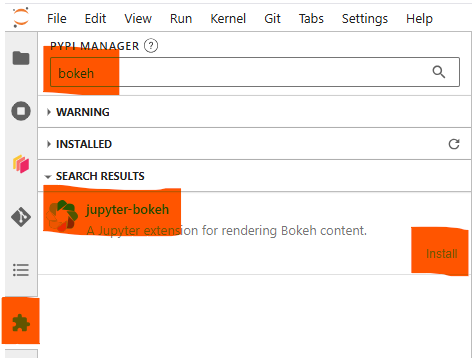

**Then refresh the webpage of the JupyterHub to make the jupyterlab extension to take effect**

In [ ]:
import panel as pn
import hvplot.xarray  # noqa: F401
import hvplot.pandas  # noqa: F401
import holoviews as hv
# https://panel.holoviz.org/api/config.html#comms-panel-comms
pn.extension(comms='default')
hv.extension("bokeh")

### A Quick Single Band Viewer

Create an interactive single-band viewer with:
- Variable selection dropdown
- Time selection dropdown
- Transparency slider
- OpenStreetMap background tiles for spatial context

In [ ]:
# Provide an xarray Dataset and some metadata for the interactive visualization
ds4vis = seasonal_means.to_dataset(name='mean_cloud_probability')
# ###### Subset the ds4vis for smaller data and faster demo ######
# Uncomment the two lines below to visualize the entire tile
ds4vis = ds4vis.rio.write_crs(scenes_filtered[0]['spatial_ref'].attrs['crs_wkt'])
ds4vis = ds4vis.rio.clip_box(minx=3.3492257, miny=49.1842377, maxx=3.5488115, maxy=49.3502127, crs="EPSG:4326")
# ###### End of subset the ds4vis for smaller data and faster demo ######
time_dim_name = 'season'
ds_crs = 'EPSG:32631'

bg_tiles = True # display the openstreetmap background tiles in the plot for better spatial context. This can be set to False if you prefer a plain background.
# Interactive plot with dropdowns to select data variable and time
# available time values
available_times = ds4vis.coords[time_dim_name].values
time_strings_quick = [str(t) for t in available_times]
# available variable names
available_vars = sorted(ds4vis.data_vars)

# Create widgets for variable and time selection
# Create a dropdown for variable selection (e.g., cloud probability, SCL, or any band)
var_select = pn.widgets.Select(
    name="Variable", 
    options=available_vars, # available variables to select in the dropdown
    value=available_vars[0] # default to the first available var
)

# Create a dropdown for time selection
time_select_quick = pn.widgets.Select(
    name="Time",
    options=dict(zip(sorted(time_strings_quick), range(len(time_strings_quick)))),
    value=0, # default to the first available time in the dataset
)

# Create a slider for transparency control of the raster layers
alpha_slider = pn.widgets.FloatSlider(name="Raster Transparency", start=0.0, end=1.0, value=0.8, step=0.05)



def plot_single_band(var_name, time_val, alpha_val):
    """Generate an interactive hvplot image for a selected variable and time step of the
    xarray Dataset that we just created `ds4vis`, with the overlay of the field
    boundaries `fields_gdf`.
    
    Creates a georeferenced raster visualization with optional OpenStreetMap 
    background tiles for spatial context. The plot is interactive and supports
    panning, zooming, and hover inspection.
    
    Args:
        var_name: Name of the data variable to plot (e.g., 'mean_cloud_probability').
        time_val: Integer index into the time/season dimension to select which
            temporal slice to display.
        alpha_val: Transparency of the raster layer (0.0 = fully transparent, 
            1.0 = fully opaque).
    
    Returns:
        holoviews.core.overlay.Overlay: A HoloViews Overlay combining the raster
            image with field boundary polygons, displayable in a Jupyter notebook
            or Panel dashboard.
    
    Note:
        This function relies on module-level variables: `ds4vis` (the xarray 
        Dataset), `time_dim_name` (name of the time dimension), `ds_crs` 
        (coordinate reference system), and `bg_tiles` (whether to show map tiles).
    """
    # Find the nearest time in the dataset
    nearest_time = ds4vis.coords[time_dim_name].values[time_val]
    image_pobj = ds4vis[var_name].sel({time_dim_name:nearest_time}).hvplot.image(
        x="x", y="y",
        frame_width=500, frame_height=500,
        data_aspect=1,
        title=f"Variable {var_name} @ {str(nearest_time)[:19]}",
        cmap="viridis",
        alpha=alpha_val,
        crs=ds_crs,
        tiles=bg_tiles
    )
    polygons_pobj = fields_gdf.hvplot.polygons(
        line_color='red', line_width=2, fill_alpha=0, tools=['hover'], title="Field Boundaries", crs=fields_gdf.crs
    )
    return image_pobj * polygons_pobj


# Use value_throttled for sliders to only update on mouse release (prevents sync errors)
single_band_plot = pn.bind(plot_single_band, var_select, time_select_quick, alpha_slider.param.value_throttled)

dashboard = pn.Column(
    pn.Row(time_select_quick, var_select, alpha_slider),
    # pn.Row(single_band_plot),
    pn.Row(pn.panel(single_band_plot, loading_indicator=True))
)

In [ ]:
# Note that when you change the widget value, it may take a while to load the data and update the plots
dashboard

## 💪 Now it is your turn


### Task 1: Explore Results for a different Sentinel-2 tile
* Access the [Sentinel-2 tile grid](https://sentiwiki.copernicus.eu/__attachments/1692737/S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.zip?inst-v=eab10fa0-1887-4666-8d61-93ebcf449302) and select a different tile-id.
* Change the tile-id [here](#query-tile-section)
* Provide a way to compare the results between different tiles, e.g. use a way to describe their spatial variance, consistency or identify extremes.

### Task 2: Time-series field level vs. tile level
* Use one tile of your choice above and define the boundaries of some agricultural fields (~10 - 20) across the tile by changing the geojson string [here](#fields-geojson).
* Derive a vegetation index per acquisition date.
* Compare the time-series between the different fields.
* What is the impact of availability of scenes across the season for agricultural applications? Can you identify patterns?

### Task 3: Putting Cloud Cover in Perspective — Sensor Limitations and Alternatives
Sentinel-2 is a passive optical sensor operating in a sun-synchronous orbit with a fixed local overpass time (~10:30 AM solar time). This means every scene captures the same time of day, and any cloud present at that moment will always obscure the observation — there is no second chance within that day.

* Look up the exact overpass time for your tile from the [Sentinel-2 acquisition schedule](https://sentiwiki.copernicus.eu/web/s2-mission). How does a fixed morning overpass affect the representativeness of the cloud statistics you computed?
* Could diurnal cloud cycles (e.g. afternoon convective clouds in summer) systematically bias the cloud probability map? Discuss for your chosen region.
* Active sensors such as Sentinel-1 SAR operate independently of cloud cover and solar illumination. When would you prefer SAR over optical data for agricultural monitoring, and what are the trade-offs (e.g. interpretation complexity, lack of spectral bands)?


## Conclusion

### What You've Accomplished

In this notebook, you've mastered a workflow for **time-series cloud probability analysis** using EOPF Sentinel-2 data. Here's what you've achieved:

#### 🎯 Key Results

1. **Pixel-Level Cloud Intelligence**: Rather than relying on metadata-level cloud coverage, you now have granular, pixel-based insights into cloud probability patterns across your study area. This enables you to distinguish between partially cloudy scenes that still contain usable data and truly unusable observations.

2. **Temporal Patterns Revealed**: By stacking and analyzing multiple scenes across years, you discovered seasonal cloud dynamics—understanding when and where persistent cloud cover occurs. This knowledge is invaluable for scheduling operational monitoring campaigns in regions with predictable cloud seasonality.

3. **Field-Level Decision Making**: You transformed satellite imagery into actionable agricultural intelligence by ranking individual fields by their observation quality. Fields with consistently clear skies can be prioritized for analysis, while fields in persistent cloud shadows can be flagged for special attention or alternative data sources.

4. **Scalable Data Processing**: You leveraged Dask for parallel computation, demonstrating how to work efficiently with large remote-sensing datasets without overwhelming local resources.

#### 💡 The Shift in Perspective

This notebook exemplifies a critical paradigm shift in Earth observation:

- **Before**: "This tile has 60% cloud cover — discard it"
- **After**: "This tile has 60% cloud cover, but fields A and B remain clear — proceed with analysis"

By integrating cloud probability analysis into your pipeline, you've transformed cloud cover from a binary rejection criterion into a nuanced quality metric that preserves usable data.

#### 🚀 Real-World Applications

Your new skillset applies directly to:

- **Agricultural Monitoring**: Identify the optimal observation windows for crop health assessments
- **Change Detection**: Mask out permanent clouds before deriving temporal statistics
- **Data Ranking**: Prioritize scenes for manual inspection or downstream processing

#### 🎓 Learning Checkpoint

You've demonstrated competency in:

✅ STAC API queries for large-scale remote sensing data  
✅ Parallel processing with Dask for geospatial data  
✅ Temporal aggregation and seasonal analysis  
✅ Spatial subsetting and masking with vector boundaries  
✅ Statistical ranking and quality assessment  
✅ Interactive visualization for stakeholder communication  

---

## What's next?

*This notebook was developed as a contribution to the [EOPF Zarr Community Notebook Competition](https://github.com/eopf-toolkit/community-notebook-competition).*
